In [1]:
#Code from garbage_classification_images and garbage_classification_text from lectures was refered to create this code.
# 1. IMPORTS 
import os
from pathlib import Path
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from transformers import BertTokenizer, BertModel
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:

# 2. CONFIG & HYPERPARAMETERS

TRAIN_DIR = '/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Train'
VAL_DIR = '/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Val'
TEST_DIR = '/work/TALC/ensf617_2026w/garbage_data/CVPR_2024_dataset_Test'

NUM_CLASSES = 4
BATCH_SIZE = 64         
EPOCHS = 10
LEARNING_RATE = 1e-4
MAX_TEXT_LEN = 32
NUM_WORKERS = 0          

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:

# 3. Data Augmentation and Transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


In [4]:

#  4. Custom Dataset Class
class GarbageDataset(Dataset):

    def __init__(self, root_dir, tokenizer, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.tokenizer = tokenizer
        self.samples = [] 

        classes = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        if not classes:
            raise ValueError(f"No class folders found in {root_dir}")
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        for cls in classes:
            cls_dir = self.root_dir / cls
            for p in cls_dir.iterdir():
                if p.suffix.lower() in (".png", ".jpg", ".jpeg"):
                    self.samples.append((str(p), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # load image
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        # create text from filename 
        text = Path(img_path).stem.replace("_", " ")

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=MAX_TEXT_LEN,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)   
        attention_mask = encoding["attention_mask"].squeeze(0)

        return img, input_ids, attention_mask, label


In [5]:

#  5. Model Definition
class MultiModalModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_p=0.3):
        super().__init__()
        # Image: pretrained ResNet50 

        try:
            self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        except Exception:
            self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = nn.Identity() 

        # Text: pretrained BERT
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # Fusion classifier
        fusion_dim = 2048 + 768
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, num_classes)
        )

    def forward(self, images, input_ids, attention_mask):
        img_feats = self.resnet(images)  
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feats = bert_out.pooler_output  
        fused = torch.cat([img_feats, text_feats], dim=1)  
        logits = self.classifier(fused)
        return logits


In [11]:

# 6. Dataloaders
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_ds = GarbageDataset(TRAIN_DIR, tokenizer, transform=train_transform)
val_ds   = GarbageDataset(VAL_DIR,   tokenizer, transform=val_transform)
test_ds  = GarbageDataset(TEST_DIR,  tokenizer, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")
print("Classes:", train_ds.class_to_idx)


Train samples: 11629
Validation samples: 1800
Test samples: 3432
Classes: {'Black': 0, 'Blue': 1, 'Green': 2, 'TTR': 3}


In [12]:

# 7. validation Function
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, input_ids, masks, labels in loader:
            images = images.to(device)
            input_ids = input_ids.to(device)
            masks = masks.to(device)
            labels = labels.to(device)

            outputs = model(images, input_ids, masks)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total



In [13]:
# 8. SETUP MODEL / LOSS / OPT
model = MultiModalModel(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

# 9. TRAIN / VALIDATE loop
best_val_loss = 1e+20
for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    train_iter = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]", leave=False)
    for images, input_ids, attention_mask, labels in train_iter:
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)  
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_train_loss = running_loss / running_total
    epoch_train_acc = running_correct / running_total

    # ---- validate ----
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, input_ids, attention_mask, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]", leave=False):
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(images, input_ids, attention_mask)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    batches = len(train_loader)
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{batches}/{batches} - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}\n")
# ---- SAVE BEST MODEL ----
    if epoch_val_loss < best_val_loss:
        print(f"Saving best model.")
        torch.save(model.state_dict(), "multimodal_garbage_best.pth")
        best_val_loss = epoch_val_loss
    print("----------------------------------------------------------------------------------")  


Epoch 1/10
182/182 - loss: 0.5384 - accuracy: 0.7988 - val_loss: 0.3324 - val_accuracy: 0.8872

Saving best model.
------------------------


Epoch 2/10
182/182 - loss: 0.2327 - accuracy: 0.9217 - val_loss: 0.2477 - val_accuracy: 0.9161

Saving best model.
------------------------


Epoch 3/10
182/182 - loss: 0.1461 - accuracy: 0.9518 - val_loss: 0.2454 - val_accuracy: 0.9233

Saving best model.
------------------------


Epoch 4/10
182/182 - loss: 0.1021 - accuracy: 0.9684 - val_loss: 0.3013 - val_accuracy: 0.9206

------------------------


Epoch 5/10
182/182 - loss: 0.0825 - accuracy: 0.9738 - val_loss: 0.2397 - val_accuracy: 0.9394

Saving best model.
------------------------


Epoch 6/10
182/182 - loss: 0.0602 - accuracy: 0.9813 - val_loss: 0.2998 - val_accuracy: 0.9311

------------------------


Epoch 7/10
182/182 - loss: 0.0498 - accuracy: 0.9845 - val_loss: 0.3021 - val_accuracy: 0.9333

------------------------


Epoch 8/10
182/182 - loss: 0.0480 - accuracy: 0.9843 - val_loss: 0.2801 - val_accuracy: 0.9311

------------------------


Epoch 9/10
182/182 - loss: 0.0383 - accuracy: 0.9883 - val_loss: 0.2901 - val_accuracy: 0.9328

------------------------


Epoch 10/10
182/182 - loss: 0.0425 - accuracy: 0.9858 - val_loss: 0.3184 - val_accuracy: 0.9361

------------------------


Testing & Evaluating: 100%|██████████| 54/54 [19:33<00:00, 21.73s/it]


Test Accuracy: 0.8330

--- Classification Report ---
              precision    recall  f1-score   support

       Black       0.73      0.72      0.73       695
        Blue       0.82      0.84      0.83      1086
       Green       0.90      0.92      0.91       799
         TTR       0.86      0.83      0.85       852

    accuracy                           0.83      3432
   macro avg       0.83      0.83      0.83      3432
weighted avg       0.83      0.83      0.83      3432



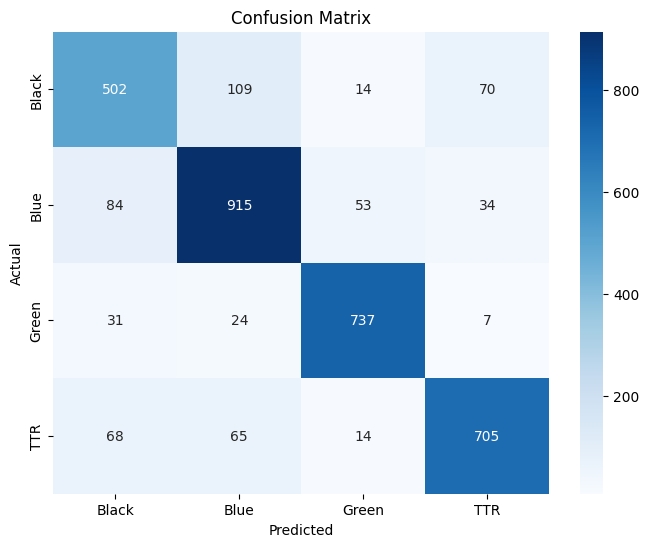


Total incorrect: 573 out of 3432


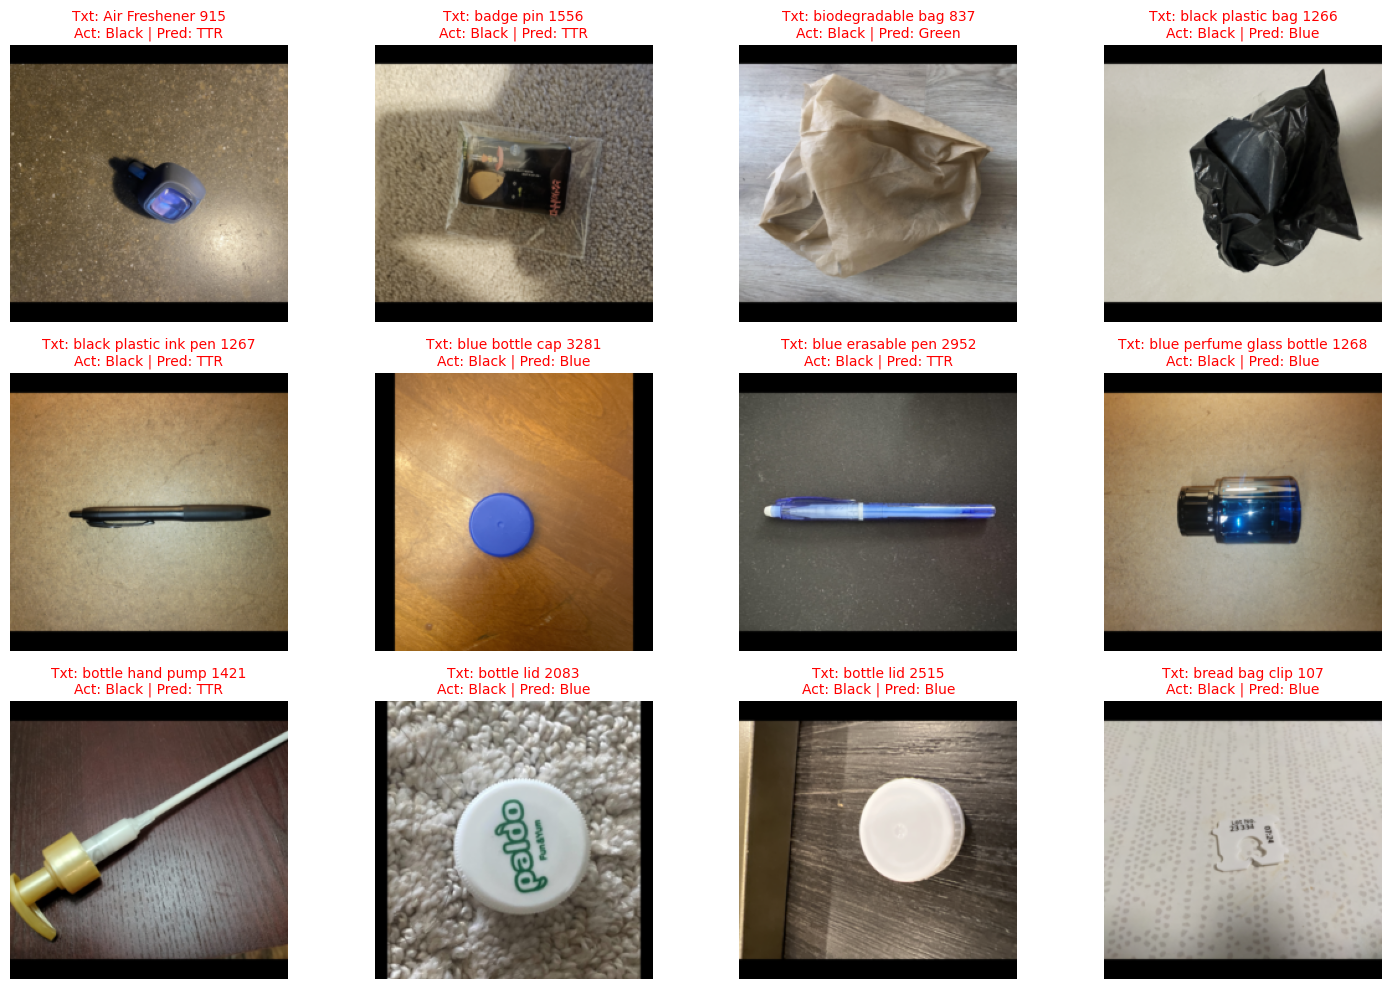

In [ ]:
# 10. TESTING & EVALUATION
model.load_state_dict(torch.load("multimodal_garbage_best.pth"))
model.to(device)
model.eval()

all_preds = []
all_labels = []

# getting labels and pritictions
with torch.no_grad():
    for images, input_ids, attention_mask, labels in tqdm(test_loader, desc="Testing & Evaluating"):
        images_gpu = images.to(device)
        input_ids_gpu = input_ids.to(device)
        attention_mask_gpu = attention_mask.to(device)

        outputs = model(images_gpu, input_ids_gpu, attention_mask_gpu)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = list(test_ds.class_to_idx.keys())

#  METRICS & CONFUSION MATRIX
test_acc = np.mean(all_preds == all_labels)
print(f"\nTest Accuracy: {test_acc:.4f} or {test_acc * 100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#  VISUALIZE FAILURES
def imshow(img_tensor, title=None):
    """Denormalize and show image"""
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array(imagenet_mean) 
    std = np.array(imagenet_std)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    if title is not None:
        plt.title(title, color='red', fontsize=10)
    plt.axis('off')


incorrect_indices = np.where(all_preds != all_labels)[0]
print(f"\nTotal incorrect: {len(incorrect_indices)} out of {len(all_labels)}")


plt.figure(figsize=(15, 10))
num_to_show = min(len(incorrect_indices), 12)

for i in range(num_to_show):
    idx = incorrect_indices[i]
    plt.subplot(3, 4, i + 1)
    
    actual_label = class_names[all_labels[idx]]
    pred_label = class_names[all_preds[idx]]

    img_tensor, _, _, _ = test_ds[idx] 
    img_path, _ = test_ds.samples[idx]
    display_text = Path(img_path).stem.replace("_", " ")

    title = f"Txt: {display_text}\nAct: {actual_label} | Pred: {pred_label}"
    imshow(img_tensor, title)

plt.tight_layout()
plt.show()